In [4]:
import tensorflow as tf
from tensorflow.keras import layers, models
import matplotlib.pyplot as plt

In [5]:
# MNIST dataset load cheyadam
(x_train, y_train), (x_test, y_test) = tf.keras.datasets.mnist.load_data()

# Pixels ni normalize cheyadam (0 to 1 range loki)
x_train, x_test = x_train / 255.0, x_test / 255.0

# Images shape ni CNN ki thaggattu marchadam
x_train = x_train.reshape(-1, 28, 28, 1)
x_test = x_test.reshape(-1, 28, 28, 1)

print("Data successfully loaded and reshaped!")
print(f"Training images count: {len(x_train)}")

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step
Data successfully loaded and reshaped!
Training images count: 60000


In [6]:
# CNN Model Design
model = models.Sequential([
    # 1. Convolutional Layer: Image lo patterns (edges, curves) ni gurthisthundi
    layers.Conv2D(32, (3, 3), activation='relu', input_shape=(28, 28, 1)),

    # 2. Max Pooling: Important features ni unchi image size ni thaggisthundi
    layers.MaxPooling2D((2, 2)),

    # 3. Second Conv Layer: Inka complex shapes ni identify chesthundhi
    layers.Conv2D(64, (3, 3), activation='relu'),
    layers.MaxPooling2D((2, 2)),

    # 4. Flatten: 2D image ni 1D list ga marchadam
    layers.Flatten(),

    # 5. Dense Layers: Ivanni mix chesi final ga adi 'ఏ నంబర్' అని చెప్తాయ్
    layers.Dense(128, activation='relu'),
    layers.Dense(10, activation='softmax') # 0 to 9 numbers kabatti 10 units
])

# Model Compilation: Goal ni set cheyadam
model.compile(optimizer='adam',
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])

print("Model architecture is ready!")
model.summary() # Model structure ela undo ikkada chudachu

Model architecture is ready!


/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 26, 26, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 13, 13, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 11, 11, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 5, 5, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 1600)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       204,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 225,034 (879.04 KB)

 Trainable params: 225,034 (879.04 KB)

 Non-trainable params: 0 (0.00 B)

In [7]:
# Model Training
# Epochs = 5 ante model motham data ni 5 sarlu chusi nerchukuntundhi
history = model.fit(x_train, y_train, epochs=5, validation_data=(x_test, y_test))

print("\nTraining Finished!")

Epoch 1/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 50s 26ms/step - accuracy: 0.9612 - loss: 0.1254 - val_accuracy: 0.9869 - val_loss: 0.0386
Epoch 2/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 48s 26ms/step - accuracy: 0.9864 - loss: 0.0423 - val_accuracy: 0.9806 - val_loss: 0.0584
Epoch 3/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 48s 26ms/step - accuracy: 0.9906 - loss: 0.0286 - val_accuracy: 0.9904 - val_loss: 0.0300
Epoch 4/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 48s 26ms/step - accuracy: 0.9937 - loss: 0.0198 - val_accuracy: 0.9888 - val_loss: 0.0359
Epoch 5/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 47s 25ms/step - accuracy: 0.9948 - loss: 0.0156 - val_accuracy: 0.9904 - val_loss: 0.0340

Training Finished!


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step


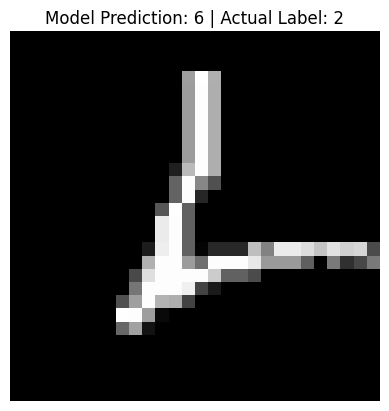

In [9]:
import numpy as np  # Ee line ni add chey
import random

# Migatha code antha alage unchu...
index = random.randint(0, 1000)
prediction = model.predict(x_test[index].reshape(1, 28, 28, 1))
predicted_label = np.argmax(prediction)

# Result ni chupinchadam
plt.imshow(x_test[index].reshape(28, 28), cmap='gray')
plt.title(f"Model Prediction: {predicted_label} | Actual Label: {y_test[index]}")
plt.axis('off')
plt.show()

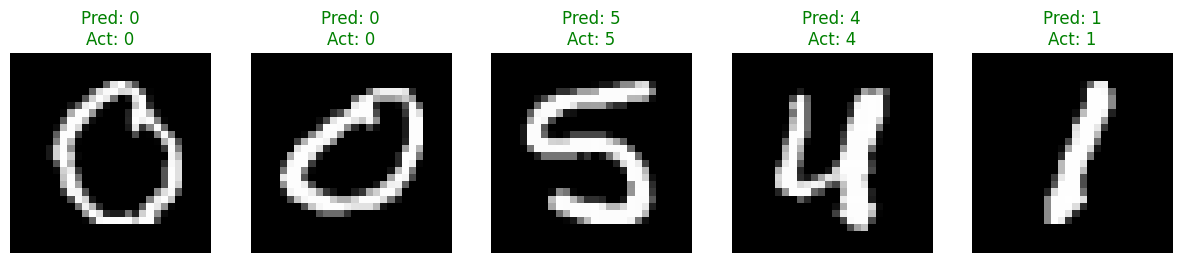

In [10]:
import numpy as np
import matplotlib.pyplot as plt
import random

# 1. Prediction function with visualization
def test_random_digits(num_images=5):
    plt.figure(figsize=(15, 5))

    for i in range(num_images):
        # Random ga oka image ni pick cheyadam
        idx = random.randint(0, len(x_test)-1)
        img = x_test[idx]

        # Model prediction
        res = model.predict(img.reshape(1, 28, 28, 1), verbose=0)
        predicted_label = np.argmax(res)
        actual_label = y_test[idx]

        # Plotting
        plt.subplot(1, num_images, i+1)
        plt.imshow(img.reshape(28, 28), cmap='gray')

        # Color: Correct ayithe Green, Thappu ayithe Red
        color = 'green' if predicted_label == actual_label else 'red'

        plt.title(f"Pred: {predicted_label}\nAct: {actual_label}", color=color)
        plt.axis('off')

    plt.show()

# Code ni run chey
test_random_digits(5)